# 06 · Sensitivity analysis (Tier 2)

**Question.** Which assumptions decide whether a new charger makes money, and therefore which
data an operator partner should provide first?

Three views, all using `profit_model.py` and the draws saved by notebook 05:

1. **Tornado (one at a time).** Start from the base case, move one assumption to its low and then
   high value, hold the rest. Bar length = swing in annual margin.
2. **Variance share (Monte Carlo).** With every assumption varying together, how much of the spread
   in margin moves with each one (squared rank correlation, normalised to 100%).
3. **Value of information.** If one assumption were known exactly (fixed at base), how much narrower
   would the P10–P90 range be? This is the most direct answer to "what data do we need?".

Reference case: **one DC 150 kW charger in San Fernando de Henares** (rank 1). A portfolio view
(one best-type charger in each top-20 zone) checks that the ordering is not specific to one zone.

In [1]:
import pickle
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from profit_model import ASSUMPTIONS, CHARGER_TYPES, evaluate, params_for, sample_params  # noqa: E402

PROC, MAPS = ROOT / "data" / "processed", ROOT / "maps"
INK, INK2, MUTED, GRID, SURF = "#0b0b0b", "#52514e", "#8a8984", "#e6e5e0", "#fcfcfb"
BLUE, RED = "#2a78d6", "#e34948"
plt.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "axes.edgecolor": GRID,
    "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
})

with open(PROC / "profit_mc_draws.pkl", "rb") as f:
    saved = pickle.load(f)
elig, draws = saved["elig"], saved["draws"]
profit = pd.read_csv(PROC / "profit_zones.csv")

REF_NAME, REF_TYPE = "San Fernando de Henares", "DC150"
ref = elig[elig.name == REF_NAME].iloc[0]
LABELS = dict(zip(ASSUMPTIONS.param, ASSUMPTIONS.label))

def margin_one(zone, ct, p):
    return float(evaluate(zone.score, zone.ev_resident_est, ct, p).margin.iloc[0])

## 1 · One-at-a-time swings

In [2]:
def tornado_table(zone, ct):
    base_p = params_for(ct, "base")
    base = margin_one(zone, ct, base_p)
    a = ASSUMPTIONS[(ASSUMPTIONS.charger == ct) | (ASSUMPTIONS.charger == "all")]
    rows = []
    for _, r in a.iterrows():
        out = {}
        for case in ["low", "high"]:
            p = dict(base_p, **{r.param: r[case]})
            res = evaluate(zone.score, zone.ev_resident_est, ct, p).iloc[0]
            out[case] = res.margin
            out[f"be_util_{case}"] = res.breakeven_util
        rows.append({"param": r.param, "label": r.label, "value_low": r.low, "value_base": r.base,
                     "value_high": r.high, "margin_low": out["low"], "margin_high": out["high"],
                     "be_util_low": out["be_util_low"], "be_util_high": out["be_util_high"]})
    t = pd.DataFrame(rows)
    t["swing"] = (t.margin_high - t.margin_low).abs()
    return base, t.sort_values("swing", ascending=False).reset_index(drop=True)

base_ref, tor = tornado_table(ref, REF_TYPE)
print(f"Base-case margin, {REF_TYPE} in {REF_NAME}: €{base_ref:,.0f}/yr")
tor.to_csv(PROC / "sensitivity_tornado_ref.csv", index=False)
tor[["label", "value_low", "value_base", "value_high", "margin_low", "margin_high", "swing"]].round(
    {"value_low": 3, "value_base": 3, "value_high": 3, "margin_low": 0, "margin_high": 0, "swing": 0})

Base-case margin, DC150 in San Fernando de Henares: €-3,384/yr


,label,value_low,value_base,value_high,margin_low,margin_high,swing
0,Utilization (time charging),0.04,0.07,0.11,-13459.0,10050.0,23509.0
1,Capex (hardware + install + grid),150000.00,110000.00,80000.00,-9345.0,1087.0,10432.0
2,Average delivered power,55.00,70.00,85.00,-8422.0,1654.0,10075.0
3,Selling price,0.52,0.59,0.69,-7397.0,2350.0,9747.0
4,Score -> utilization slope,0.25,0.50,0.75,-7302.0,534.0,7836.0
5,Net demand growth per charger,0.00,0.04,0.08,-6821.0,805.0,7626.0
6,Asset lifetime,8.00,10.00,12.00,-6885.0,-845.0,6040.0
7,Capex subsidy,0.00,0.00,0.30,-3384.0,1534.0,4918.0
8,"Electricity cost (variable, all-in)",0.16,0.13,0.10,-5765.0,-1002.0,4763.0
9,Fixed power charge (termino de potencia),45.00,30.00,15.00,-5634.0,-1134.0,4500.0


**Break-even utilization under each swing.** The same exercise, reported as the utilization the
charger would need (base case: see first row's base). Utilization itself is absent from the
break-even column's drivers by construction; it is what break-even is compared against.

In [3]:
be_base = evaluate(ref.score, ref.ev_resident_est, REF_TYPE, params_for(REF_TYPE)).breakeven_util.iloc[0]
print(f"Base break-even utilization: {be_base:.1%}")
(tor[~tor.param.isin(["util", "elasticity", "kwh_per_ev", "public_share", "capture"])]
    [["label", "be_util_low", "be_util_high"]]
    .assign(be_util_low=lambda d: (d.be_util_low * 100).round(1),
            be_util_high=lambda d: (d.be_util_high * 100).round(1))
    .rename(columns={"be_util_low": "break-even % (pessimistic value)",
                     "be_util_high": "break-even % (optimistic value)"}))

Base break-even utilization: 12.0%


,label,break-even % (pessimistic value),break-even % (optimistic value)
1,Capex (hardware + install + grid),14.7,10.0
2,Average delivered power,15.3,9.9
3,Selling price,14.5,9.7
5,Net demand growth per charger,14.1,10.2
6,Asset lifetime,13.7,10.9
7,Capex subsidy,12.0,9.8
8,"Electricity cost (variable, all-in)",13.4,10.9
9,Fixed power charge (termino de potencia),13.0,11.0
10,"Opex (maintenance, software, SIM, insurance, s...",12.9,11.3
11,Discount rate (WACC),12.8,11.3


## 2 · Tornado chart

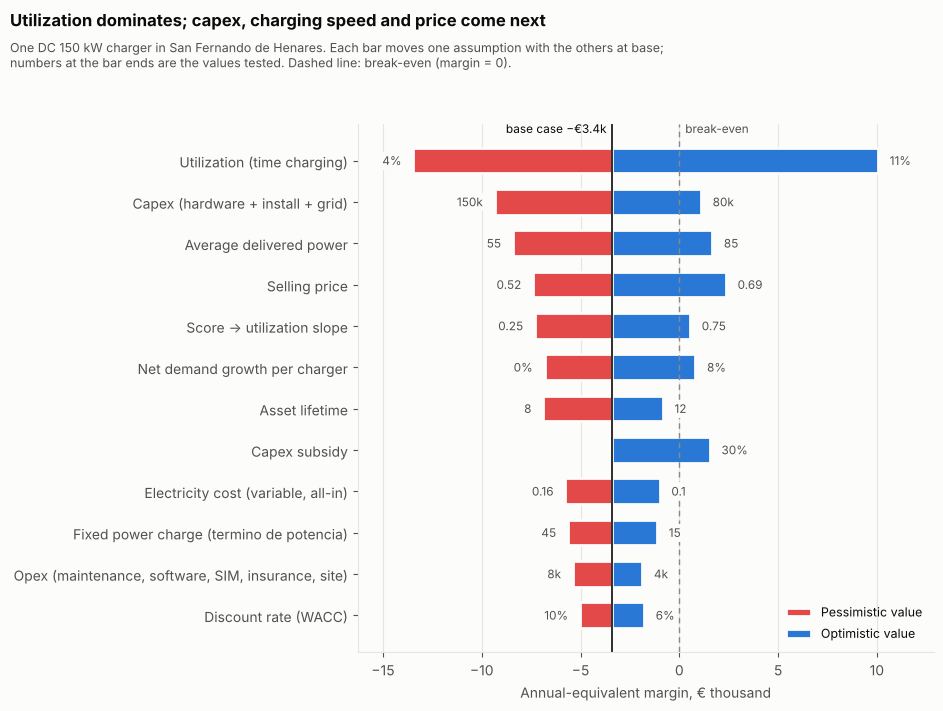

In [4]:
def plot_tornado(t, base, title, subtitle, path, top=12):
    t = t.head(top).iloc[::-1]
    y = np.arange(len(t))
    fig, ax = plt.subplots(figsize=(9.5, 0.42 * len(t) + 2.2))
    lo, hi = t.margin_low / 1e3, t.margin_high / 1e3
    b = base / 1e3
    ax.barh(y, lo - b, left=b, height=0.62, color=RED, label="Pessimistic value",
            edgecolor=SURF, linewidth=2)
    ax.barh(y, hi - b, left=b, height=0.62, color=BLUE, label="Optimistic value",
            edgecolor=SURF, linewidth=2)
    ax.axvline(b, color=INK, lw=1.2)
    ax.axvline(0, color=MUTED, lw=1, ls=(0, (4, 3)))

    def fmt(v, unit):
        if "share" in unit or unit == "per year":
            return f"{v:.0%}" if v >= 0.01 or v == 0 else f"{v:.1%}"
        if v >= 1000:
            return f"{v/1000:.0f}k"
        return f"{v:g}"

    for yi, (_, r) in zip(y, t.iterrows()):
        unit = ASSUMPTIONS.loc[ASSUMPTIONS.param == r.param, "unit"].iloc[0]
        for end, val in [(r.margin_low / 1e3, r.value_low), (r.margin_high / 1e3, r.value_high)]:
            if abs(end - b) < 1e-9:
                continue  # value equals base (e.g. no subsidy): no bar, no label
            right = end >= b
            ax.text(end + (0.6 if right else -0.6), yi, fmt(val, unit), va="center",
                    ha="left" if right else "right", fontsize=8.5, color=INK2,
                    bbox=dict(boxstyle="square,pad=0.15", fc=SURF, ec="none"))
    ax.set_yticks(y, t.label)
    ax.set_xlabel("Annual-equivalent margin, € thousand")
    H = fig.get_figheight()
    fig.suptitle(title, x=0.012, y=1 - 0.18 / H, ha="left", va="top", fontsize=12, fontweight="bold")
    fig.text(0.012, 1 - 0.48 / H, subtitle, ha="left", va="top", color=INK2, fontsize=9)
    ax.grid(axis="x", color=GRID, lw=0.8)
    ax.set_axisbelow(True)
    xmin, xmax = min(lo.min(), hi.min()), max(lo.max(), hi.max())
    ax.set_xlim(xmin - 0.12 * (xmax - xmin), xmax + 0.12 * (xmax - xmin))
    sign = "−" if base < 0 else ""
    ax.text(b - 0.3, len(t) - 0.4, f"base case {sign}€{abs(base)/1e3:,.1f}k", ha="right", va="bottom",
            fontsize=8.5, color=INK)
    ax.text(0.3, len(t) - 0.4, "break-even", ha="left", va="bottom", fontsize=8.5, color=INK2)
    ax.legend(loc="lower right", frameon=False, fontsize=9)
    fig.tight_layout(rect=(0, 0, 1, 1 - 0.8 / H))
    fig.savefig(path, dpi=200)
    plt.show()

plot_tornado(tor, base_ref,
             "Utilization dominates; capex, charging speed and price come next",
             f"One DC 150 kW charger in {REF_NAME}. Each bar moves one assumption with the others at base;\n"
             "numbers at the bar ends are the values tested. Dashed line: break-even (margin = 0).",
             MAPS / "tornado_dc150_ref.png")

## 3 · Portfolio check: top-20 zones, best charger type each

In [5]:
top = profit[profit["rank"] <= 20][["ine_code", "best_charger"]].merge(elig, on="ine_code")

def portfolio_margin(override_param=None, case=None):
    total = 0.0
    for _, z in top.iterrows():
        p = params_for(z.best_charger, "base")
        if override_param is not None:
            row = ASSUMPTIONS[(ASSUMPTIONS.param == override_param) &
                              ASSUMPTIONS.charger.isin([z.best_charger, "all"])].iloc[0]
            p[override_param] = row[case]
        total += margin_one(z, z.best_charger, p)
    return total

base_pf = portfolio_margin()
rows = []
for prm in ASSUMPTIONS.param.unique():
    lo, hi = portfolio_margin(prm, "low"), portfolio_margin(prm, "high")
    rows.append({"param": prm, "label": LABELS[prm], "margin_low": lo, "margin_high": hi,
                 "swing": abs(hi - lo)})
tor_pf = pd.DataFrame(rows).sort_values("swing", ascending=False).reset_index(drop=True)
capex_pf = sum(params_for(c)["capex"] for c in top.best_charger)
print(f"Portfolio: {len(top)} chargers, base capex €{capex_pf:,.0f}, base margin €{base_pf:,.0f}/yr")
print("Rank agreement with single-zone tornado (Spearman on swings):",
      round(spearmanr(tor.set_index("param").swing, tor_pf.set_index("param").swing.reindex(tor.param))[0], 2))
tor_pf.to_csv(PROC / "sensitivity_tornado_portfolio.csv", index=False)
tor_pf[["label", "margin_low", "margin_high", "swing"]].round(0)

Portfolio: 20 chargers, base capex €1,745,000, base margin €-111,055/yr
Rank agreement with single-zone tornado (Spearman on swings): 0.97


,label,margin_low,margin_high,swing
0,Utilization (time charging),-248413.0,70586.0,318999.0
1,Capex (hardware + install + grid),-204198.0,-39372.0,164827.0
2,Selling price,-167787.0,-35068.0,132719.0
3,Average delivered power,-177003.0,-45106.0,131897.0
4,Net demand growth per charger,-157910.0,-53951.0,103959.0
5,Asset lifetime,-164915.0,-72429.0,92486.0
6,Capex subsidy,-111055.0,-33038.0,78017.0
7,Score -> utilization slope,-146036.0,-76073.0,69963.0
8,Fixed power charge (termino de potencia),-145555.0,-76555.0,69000.0
9,"Electricity cost (variable, all-in)",-144716.0,-77394.0,67322.0


## 4 · Variance share and value of information (Monte Carlo)

In [6]:
ps, M = draws[REF_TYPE]
iref = int(np.where(elig.name.values == REF_NAME)[0][0])
y_mc = M[iref]
rho2 = {k: spearmanr(v, y_mc)[0] ** 2 for k, v in ps.items() if np.ptp(v) > 0}
share = pd.Series(rho2).sort_values(ascending=False)
share = (share / share.sum()).rename("variance_share")

# Value of information: fix one assumption at base, re-draw nothing else (same draws), re-evaluate.
w_all = np.quantile(y_mc, 0.9) - np.quantile(y_mc, 0.1)
voi = {}
for k in ps:
    p_fixed = dict(ps)
    p_fixed[k] = np.full_like(ps[k], params_for(REF_TYPE)[k])
    m = evaluate(ref.score, ref.ev_resident_est, REF_TYPE, p_fixed).margin.values
    voi[k] = 1 - (np.quantile(m, 0.9) - np.quantile(m, 0.1)) / w_all
voi = pd.Series(voi, name="p10_p90_narrowing")

gsa = pd.concat([share, voi], axis=1).fillna(0).sort_values("variance_share", ascending=False)
gsa.index = [LABELS[i] for i in gsa.index]
gsa.to_csv(PROC / "sensitivity_global.csv")
print(f"P10–P90 width with everything uncertain: €{w_all:,.0f}")
(gsa * 100).round(1)

P10–P90 width with everything uncertain: €17,476


,variance_share,p10_p90_narrowing
Utilization (time charging),49.4,30.7
Average delivered power,9.7,5.6
Capex (hardware + install + grid),9.0,5.3
Selling price,7.7,7.0
Score -> utilization slope,5.5,2.9
Net demand growth per charger,5.2,3.2
Capex subsidy,3.1,1.5
Asset lifetime,3.1,-1.7
"Electricity cost (variable, all-in)",2.5,1.9
"Opex (maintenance, software, SIM, insurance, site)",1.7,1.4


**By data source.** An operator partner hands over data in bundles, not one parameter at a time.
Fixing a whole bundle at its base value shows what each kind of data is worth. Single-input
narrowing can be slightly negative (fixing an input at its mode does not always shrink a skewed
range); bundles avoid most of that noise.

In [7]:
GROUPS = {
    "Session logs (utilization, power, growth, score link)": ["util", "avg_kw", "demand_growth", "elasticity"],
    "Site & hardware quotes (capex, opex, subsidy, life)": ["capex", "opex", "subsidy", "lifetime"],
    "Tariff & pricing (selling price, fees)": ["price", "fee_share"],
    "Energy contract (electricity, power charge)": ["energy_cost", "power_charge"],
    "Finance (discount rate)": ["discount_rate"],
}
grp = {}
for gname, keys in GROUPS.items():
    p_fixed = dict(ps)
    for k in keys:
        p_fixed[k] = np.full_like(ps[k], params_for(REF_TYPE)[k])
    m = evaluate(ref.score, ref.ev_resident_est, REF_TYPE, p_fixed).margin.values
    grp[gname] = 1 - (np.quantile(m, 0.9) - np.quantile(m, 0.1)) / w_all
grp = pd.Series(grp, name="p10_p90_narrowing").sort_values()
grp.to_csv(PROC / "sensitivity_value_of_information.csv")
(grp * 100).round(1)

Finance (discount rate)                                   0.9
Energy contract (electricity, power charge)               2.4
Site & hardware quotes (capex, opex, subsidy, life)       5.1
Tariff & pricing (selling price, fees)                    7.1
Session logs (utilization, power, growth, score link)    46.6
Name: p10_p90_narrowing, dtype: float64

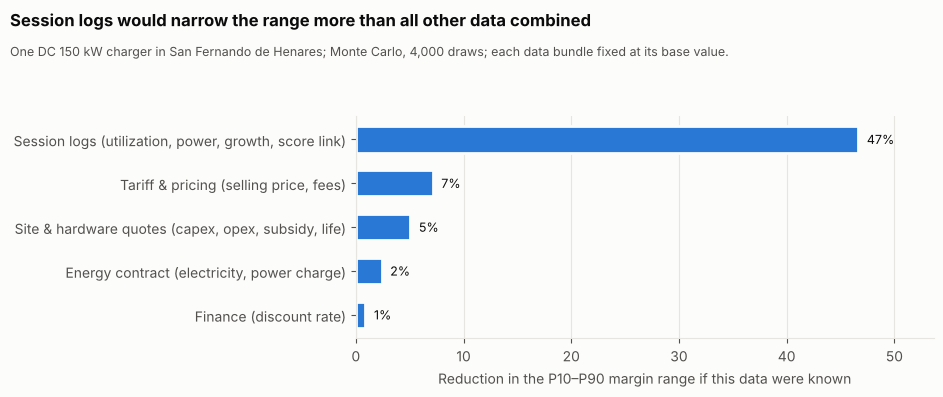

In [8]:
fig, ax = plt.subplots(figsize=(9.5, 4))
yy = np.arange(len(grp))
ax.barh(yy, grp * 100, height=0.6, color=BLUE, edgecolor=SURF, linewidth=2)
for yi, v in zip(yy, grp * 100):
    ax.text(v + 0.8, yi, f"{v:.0f}%", va="center", fontsize=9, color=INK)
ax.set_yticks(yy, grp.index)
ax.set_xlabel("Reduction in the P10–P90 margin range if this data were known")
fig.suptitle("Session logs would narrow the range more than all other data combined",
             x=0.012, ha="left", fontsize=12, fontweight="bold")
fig.text(0.012, 0.865, f"One DC 150 kW charger in {REF_NAME}; Monte Carlo, {len(y_mc):,} draws; "
         "each data bundle fixed at its base value.", ha="left", color=INK2, fontsize=9)
ax.grid(axis="x", color=GRID, lw=0.8)
ax.set_axisbelow(True)
ax.set_xlim(0, grp.max() * 100 * 1.15)
fig.tight_layout(rect=(0, 0, 1, 0.84))
fig.savefig(MAPS / "value_of_information.png", dpi=200)
plt.show()

## 5 · What would flip the base case?

For the reference zone: how far each lever has to move, alone, for the base-case margin to reach
zero. Solved by bisection between the base value and a wide bound.

In [9]:
def flip_value(param, lo, hi, zone=ref, ct=REF_TYPE, tol=1e-6):
    base_p = params_for(ct)
    f = lambda v: margin_one(zone, ct, dict(base_p, **{param: v}))
    if np.sign(f(lo)) == np.sign(f(hi)):
        return np.nan
    for _ in range(80):
        mid = (lo + hi) / 2
        if np.sign(f(mid)) == np.sign(f(lo)):
            lo = mid
        else:
            hi = mid
    return (lo + hi) / 2

bp = params_for(REF_TYPE)
flip = pd.DataFrame([
    ("Utilization (base, at score 50)", "util", bp["util"], flip_value("util", bp["util"], 0.5)),
    ("Selling price, € / kWh incl. VAT", "price", bp["price"], flip_value("price", bp["price"], 2.0)),
    ("Capex, €", "capex", bp["capex"], flip_value("capex", 0, bp["capex"])),
    ("Capex subsidy, share", "subsidy", bp["subsidy"], flip_value("subsidy", 0, 0.99)),
    ("Electricity cost, € / kWh", "energy_cost", bp["energy_cost"], flip_value("energy_cost", 0, bp["energy_cost"])),
    ("Fixed power charge, € / kW / yr", "power_charge", bp["power_charge"], flip_value("power_charge", 0, bp["power_charge"])),
    ("Net demand growth, per year", "demand_growth", bp["demand_growth"], flip_value("demand_growth", bp["demand_growth"], 0.5)),
], columns=["lever", "param", "base", "break_even_value"])
flip["change_needed"] = flip.break_even_value / flip.base.replace(0, np.nan) - 1
flip.to_csv(PROC / "sensitivity_flip_points.csv", index=False)
flip

,lever,param,base,break_even_value,change_needed
0,"Utilization (base, at score 50)",util,0.07,0.080075,0.143934
1,"Selling price, € / kWh incl. VAT",price,0.59,0.649016,0.100028
2,"Capex, €",capex,110000.00,87294.359787,-0.206415
3,"Capex subsidy, share",subsidy,0.00,0.206415,NaN
4,"Electricity cost, € / kWh",energy_cost,0.13,0.087372,-0.327910
5,"Fixed power charge, € / kW / yr",power_charge,30.00,7.441267,-0.751958
6,"Net demand growth, per year",demand_growth,0.04,0.072903,0.822571
